<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 6. Redes Avanzadas</font></h1>

<h1><font color="#113D68" size=4>2. Regularización</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Cargar el dataset](#section1)
* [2. Procesamiento de datos](#section2)
* [3. Arquitectura Neuronal](#section3)
* [4. Regularización L2](#section4)
* [5. Early Stopping](#section5)
* [6. Dropout](#section6)
* [7. Usar más datos](#section7)
* [8. Data Augmetantion](#section8)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

Como hemos visto en el post anterior, cuando entrenamos redes neuronales corremos el riesgo de hacer overfitting a los datos de entrenamiento, lo cual se traducirá en una mal rendimiento de nuestro modelo cuando le demos datos que no ha visto durante el entrenamiento, no sabrá generalizar. La mejor manera de saber si nuestro modelo sufre de este problema, es observar las curvas de entrenamiento. Vamos a entrenar un MLP en el dataset CIFAR10 para clasificación de imágenes en 10 clases diferentes.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch tutorials: [Training a Classifier](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html).

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Cargar el dataset</font>

Este dataset está formado por imágenes en color de baja resolución, tenemos 50000 imágenes de entrenamiento y 10000 de test y el objetivo es el clasificar en 10 clases diferentes. Veamos algunos ejemplos.

In [1]:
import torchvision

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

len(trainset), len(testset)

/Users/manwest/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Using downloaded and verified file: ./data/cifar-10-python.tar.gz
Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


(50000, 10000)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`CIFAR10`](https://www.cs.toronto.edu/~kriz/cifar.html)

Veamos como son estas imágenes

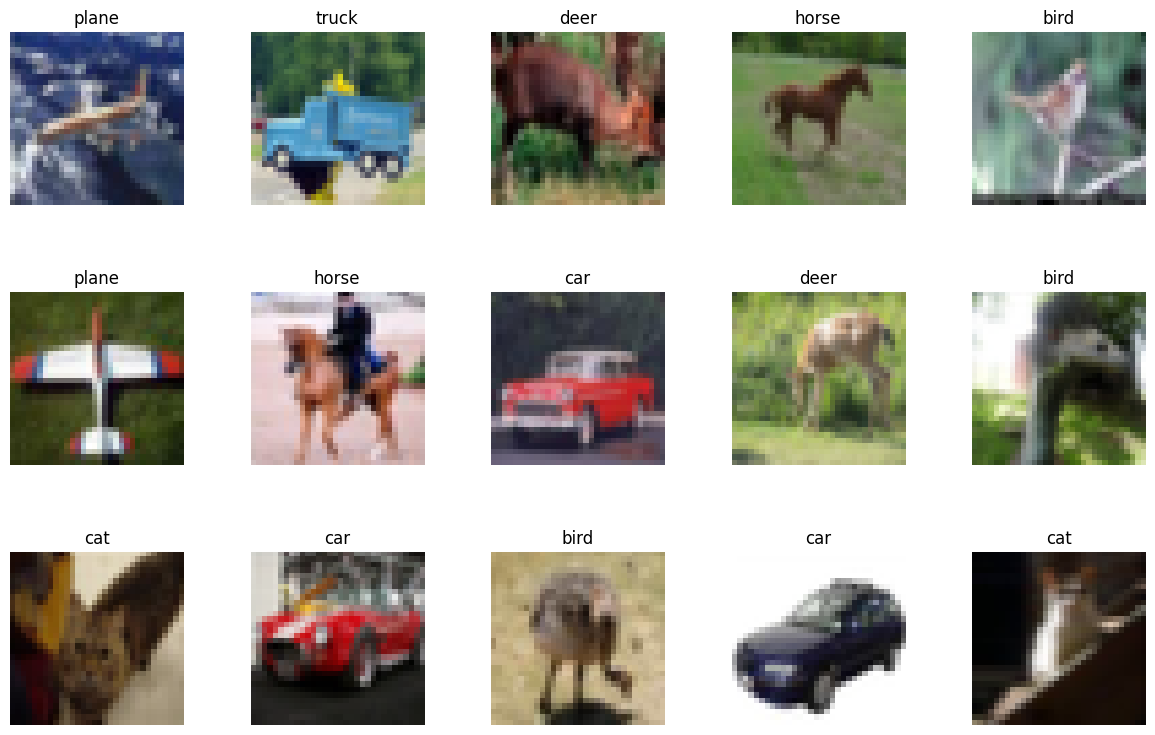

In [2]:
import random 
import matplotlib.pyplot as plt

r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
    for col in range(c):
        index = c*row + col
        plt.subplot(r, c, index + 1)
        ix = random.randint(0, len(trainset)-1)
        img, label = trainset[ix]
        plt.imshow(img)
        plt.axis('off')
        plt.title(classes[label])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Procesamiento de datos</font>

Vamos a transformar las imágenes en arrays de NumPy para poder manejar las imágenes. 

También separaremos un conjunto de imágenes para validación así como un subset de imágenes para entrenar más rápido.

In [3]:
import numpy as np

train_images = np.array([np.array(img) for img, label in trainset])
X_test = np.array([np.array(img) for img, label in testset])

train_labels = np.array([label for img, label in trainset])
y_test = np.array([label for img, label in testset])

X_train, X_val, X_subset = train_images[:40000], train_images[40000:], train_images[:5000]  # subset pequeño para provocar overfitting
y_train, y_val, y_subset = train_labels[:40000], train_labels[40000:], train_labels[:5000]

X_train.shape, X_val.shape, X_test.shape, X_subset.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3), (5000, 32, 32, 3))

Preparamos el iterador para poder la carga de datos y entrenamiento.

In [4]:
import torch
# Configurar el dispositivo
if torch.cuda.is_available():
    device = torch.device("cuda")  # Usar GPU con CUDA
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Usar GPU con Metal (macOS)
else:
    device = torch.device("cpu")   # Usar CPU como alternativa

print(f"Usando el dispositivo: {device}")

Usando el dispositivo: mps


In [6]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        # Convertir los datos al dispositivo adecuado
        self.X = torch.from_numpy(X / 255.).float().view(len(X), -1).to(device)  # aplanar 32x32x3 -> 3072
        self.Y = torch.from_numpy(Y).long().to(device)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

# Crear los conjuntos de datos y cargadores
dataset = {
    'train': Dataset(X_subset, y_subset),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False),
}

len(dataset['train']), len(dataset['val'])

(5000, 10000)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>4. Arquitectura Neuronal</font>

Realizamos el código para entrenar un MLP en esta tarea y ver las curvas de entrenamiento.

In [ ]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def build_model(D_in=32*32*3, H=100, D_out=10):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).to(device)

def fit(model, dataloader, epochs=100, log_each=10, weight_decay=0):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay)  # weight_decay = regularización L2
    l, acc = [], []
    val_l, val_acc = [], []
    for e in range(1, epochs+1): 
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)            
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)            
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    return {'epoch': list(range(1, epochs+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

In [10]:
model = build_model()
hist = fit(model, dataloader)


Epoch 10/100 loss 1.69840 acc 0.38217 val_loss 1.91491 val_acc 0.33207
Epoch 20/100 loss 1.49339 acc 0.45263 val_loss 2.62670 val_acc 0.24161
Epoch 30/100 loss 1.30832 acc 0.51951 val_loss 2.65507 val_acc 0.26577
Epoch 40/100 loss 1.12314 acc 0.58798 val_loss 3.05619 val_acc 0.31200
Epoch 50/100 loss 1.06258 acc 0.62042 val_loss 2.36329 val_acc 0.36651
Epoch 60/100 loss 0.88554 acc 0.67158 val_loss 5.19557 val_acc 0.25369
Epoch 70/100 loss 0.83028 acc 0.70362 val_loss 4.02779 val_acc 0.30302
Epoch 80/100 loss 0.72389 acc 0.74602 val_loss 3.90206 val_acc 0.34036
Epoch 90/100 loss 0.57535 acc 0.79339 val_loss 4.03721 val_acc 0.33287
Epoch 100/100 loss 0.68594 acc 0.76752 val_loss 3.75034 val_acc 0.34275


- Como podemos observar de las curvas de entrenamiento, las métricas para el conjunto de datos de entrenamiento van mejorando epoch tras epoch
- Sin embargo las métricas de validación rápidamente se estancan y empiezan a empeorar. 
- Esta es la señal clara de que nuestro modelo está sufriendo de overfitting
- Ahora veremos diferentes técnicas de regularización, el término técnico utilizado para referirnos a las diferentes técnicas de reducción de overfitting.

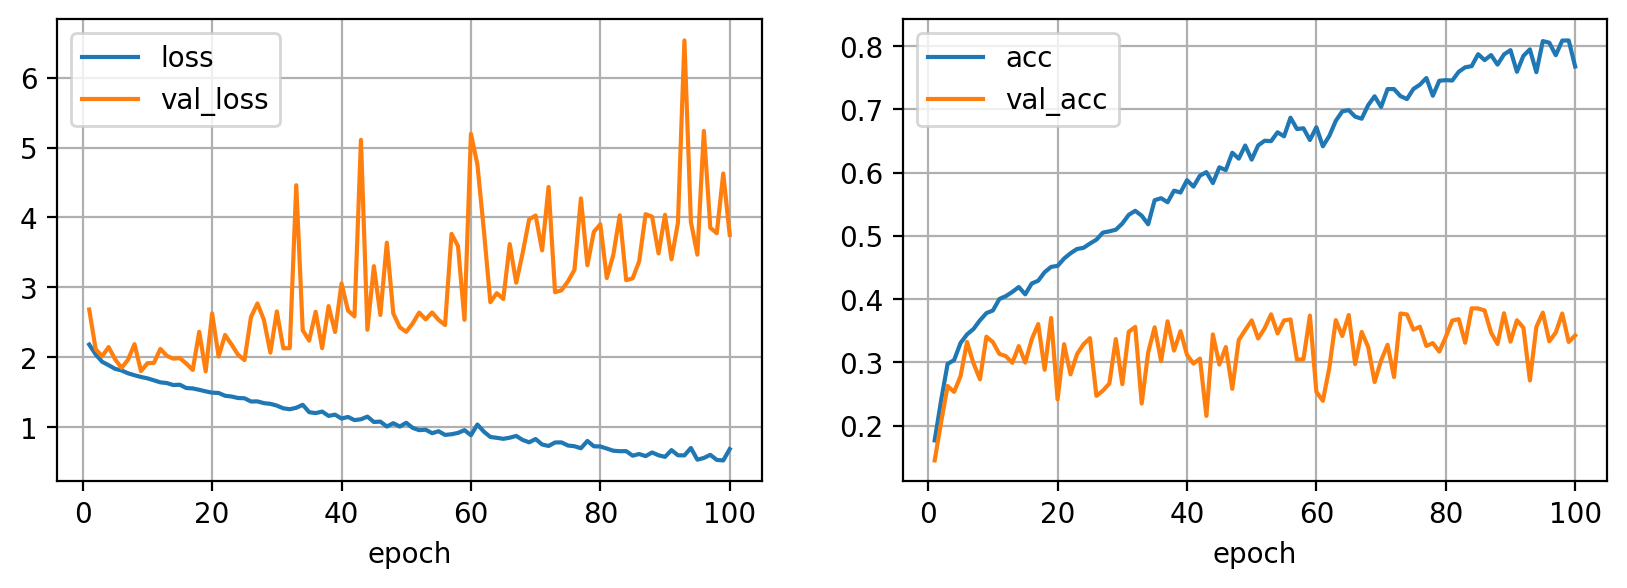

In [11]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section4"></a>
# <font color="#004D7F" size=6>4. Regularización L2</font>

- Una técnica de regularización muy utilizada es la **regularización L2**. 
- Esta técnica consiste en restringir la magnitud de los pesos de la red neuronal forzándolos a ser valores pequeños. 
- A efectos prácticos, la regularización L2 se implementa como un término extra en la función de pérdida

A continuación se presenta la fórmula oficial de la regularización L2:

$$l = CE(\hat{y}, y) + \alpha \frac{1}{2}||w||
$$

donde, 
- $CE(\hat{y}, y)$ es la  función cross entropy (o cualquier función de pérdida que uses dependiendo de tu caso), 
- $\mathbf{w}$ son los pesos de la red $y$ 
- $\alpha$ es un parámetro indicando cuánto queremos regularizar el modelo. 

En Pytorch podemos asignar el valor de $\alpha$ mediante el parámetro `wieght_decay` directamente en el optimizador (por defecto está a 0). 
- Valores típicos utilizados se encuentran en el rango 0.001 - 0.01.

In [12]:
model = build_model()
hist = fit(model, dataloader, weight_decay=0.01)

Epoch 10/100 loss 1.85482 acc 0.32524 val_loss 2.54403 val_acc 0.22684
Epoch 20/100 loss 1.79549 acc 0.34415 val_loss 1.91128 val_acc 0.27276
Epoch 30/100 loss 1.77064 acc 0.35689 val_loss 1.97683 val_acc 0.29343
Epoch 40/100 loss 1.77163 acc 0.35808 val_loss 2.44700 val_acc 0.19728
Epoch 50/100 loss 1.76644 acc 0.36087 val_loss 1.96762 val_acc 0.29054
Epoch 60/100 loss 1.72667 acc 0.36823 val_loss 1.97785 val_acc 0.31210
Epoch 70/100 loss 1.73881 acc 0.36843 val_loss 2.09483 val_acc 0.26727
Epoch 80/100 loss 1.74638 acc 0.37440 val_loss 1.84057 val_acc 0.33317
Epoch 90/100 loss 1.75204 acc 0.37201 val_loss 2.39739 val_acc 0.17382
Epoch 100/100 loss 1.76939 acc 0.36365 val_loss 1.99176 val_acc 0.28015


Como puedes observar ahora las curvas de entrenamiento y validación están más próximas, por lo que hemos disminuido el overfitting. Es importante remarcar que reducir el overfitting no implica mejorar las métricas.

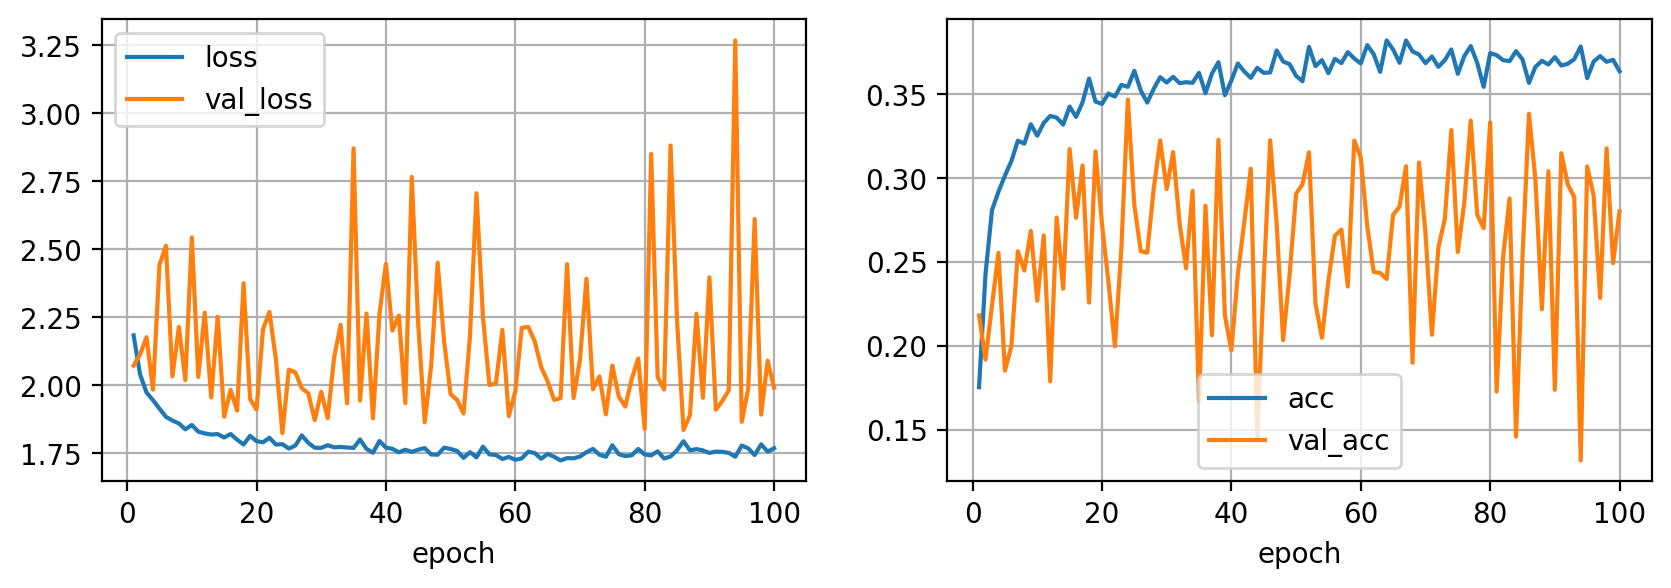

In [13]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section5"></a>
# <font color="#004D7F" size=6>5. Early Stopping</font>

Otra técnica muy utilizada para regularizar un modelo es el early stopping. 
- Consiste en llevar un registro de las métricas de validación durante el entrenamiento, guardar los pesos del modelo cada vez que mejoramos las mejores métricas obtenidas y, 
- Una vez terminado el entrenamiento, cargar los mejores pesos en vez de quedarnos con los últimos. 
- De forma opcional también podemos detener el entrenamiento si no mejoramos nuestras métricas durante un número determinado de epocas, lo cual puede traducirse en un ahorro de tiempo y cómputo.

In [ ]:
def fit(model, dataloader, epochs=100, log_each=10, weight_decay=0, early_stopping=None):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay)
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1): 
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)            
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)            
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0  # reiniciar el contador de épocas sin mejora
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step >= early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

- Si comparas esta figura con la primera, podrás observar que si seguimos entrenando más epochs no vamos a encontrar un modelo mejor
- Por lo tanto no es necesario seguir entrenando ya que en este punto ya hemos encontrado el mejor modelo posible dadas las circunstancias. 
- Early stopping es una técnica muy sencilla y efectiva, por lo que es recomendable utilizarla siempre.

In [15]:
model = build_model()
hist = fit(model, dataloader, epochs=100, early_stopping=10)

Mejor modelo guardado con acc 0.18660 en epoch 1
Mejor modelo guardado con acc 0.22214 en epoch 2
Mejor modelo guardado con acc 0.27855 en epoch 4
Mejor modelo guardado con acc 0.29363 en epoch 6
Mejor modelo guardado con acc 0.30132 en epoch 10
Epoch 10/100 loss 1.70064 acc 0.38356 val_loss 2.04783 val_acc 0.30132
Mejor modelo guardado con acc 0.33137 en epoch 11
Mejor modelo guardado con acc 0.33506 en epoch 14
Mejor modelo guardado con acc 0.35294 en epoch 17
Mejor modelo guardado con acc 0.35503 en epoch 19
Epoch 20/100 loss 1.50610 acc 0.44984 val_loss 1.96457 val_acc 0.34315
Entrenamiento detenido en epoch 29 por no mejorar en 10 epochs seguidas


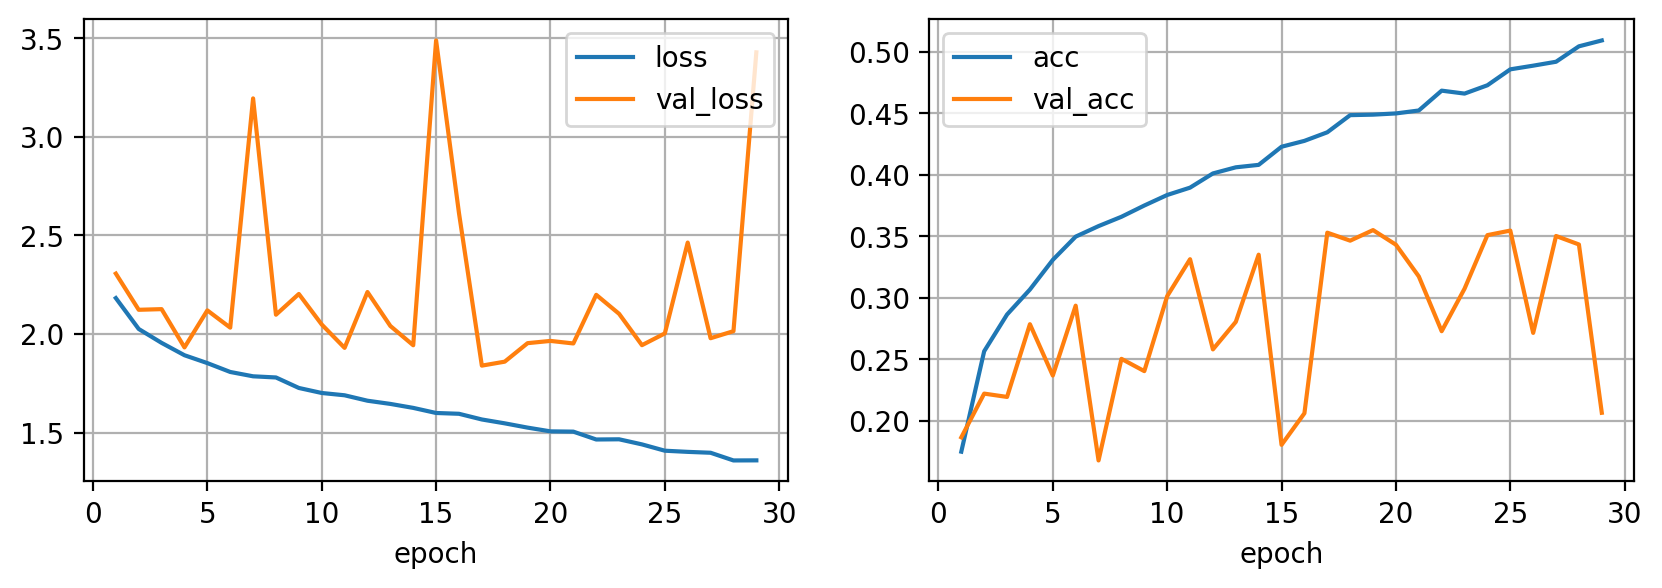

In [16]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section6"></a>
# <font color="#004D7F" size=6>6. Dropout</font>

- Esta técnica se implementa como una capa extra en nuestra red neuronal
- "apaga" de manera aleatoria algunas neuronas de manera que forzaremos a nuestro modelo a aprender diferentes caminos dentro de la arquitectura para representar los mismos datos.
- Puedes añadir una capa de Dropout con la clase `torch.nn.Dropout`. 
- El parámetro `p` controla la probabilidad de "apagar" una neurona. 
- Este valor `p` coincide con la proporción (en promedio) de neuronas que serán anuladas en una capa determinada.

In [ ]:
def build_model(D_in=32*32*3, H=100, D_out=10, p=0.5):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, D_out)
    ).to(device)

In [21]:
model = build_model(p=0.5)
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.16354 en epoch 1
Mejor modelo guardado con acc 0.22264 en epoch 2
Mejor modelo guardado con acc 0.26238 en epoch 3
Mejor modelo guardado con acc 0.29722 en epoch 7
Mejor modelo guardado con acc 0.29842 en epoch 8
Epoch 10/100 loss 1.83641 acc 0.33499 val_loss 2.06549 val_acc 0.23602
Mejor modelo guardado con acc 0.29932 en epoch 14
Mejor modelo guardado con acc 0.30591 en epoch 15
Mejor modelo guardado con acc 0.32398 en epoch 17
Mejor modelo guardado con acc 0.33606 en epoch 20
Epoch 20/100 loss 1.73323 acc 0.36963 val_loss 1.82814 val_acc 0.33606
Mejor modelo guardado con acc 0.34505 en epoch 27
Mejor modelo guardado con acc 0.34934 en epoch 30
Epoch 30/100 loss 1.65459 acc 0.40107 val_loss 1.80921 val_acc 0.34934
Mejor modelo guardado con acc 0.34984 en epoch 32
Mejor modelo guardado con acc 0.37330 en epoch 35
Epoch 40/100 loss 1.56764 acc 0.42277 val_loss 1.96880 val_acc 0.28125
Entrenamiento detenido en epoch 45 por no mejorar en 10 epochs seguidas

- De nuevo observamos que las curvas de entrenamiento ya no presentan overfitting. 
- Puedes jugar con la probabilidad de Dropout para controlar su efecto en el resultado final. 

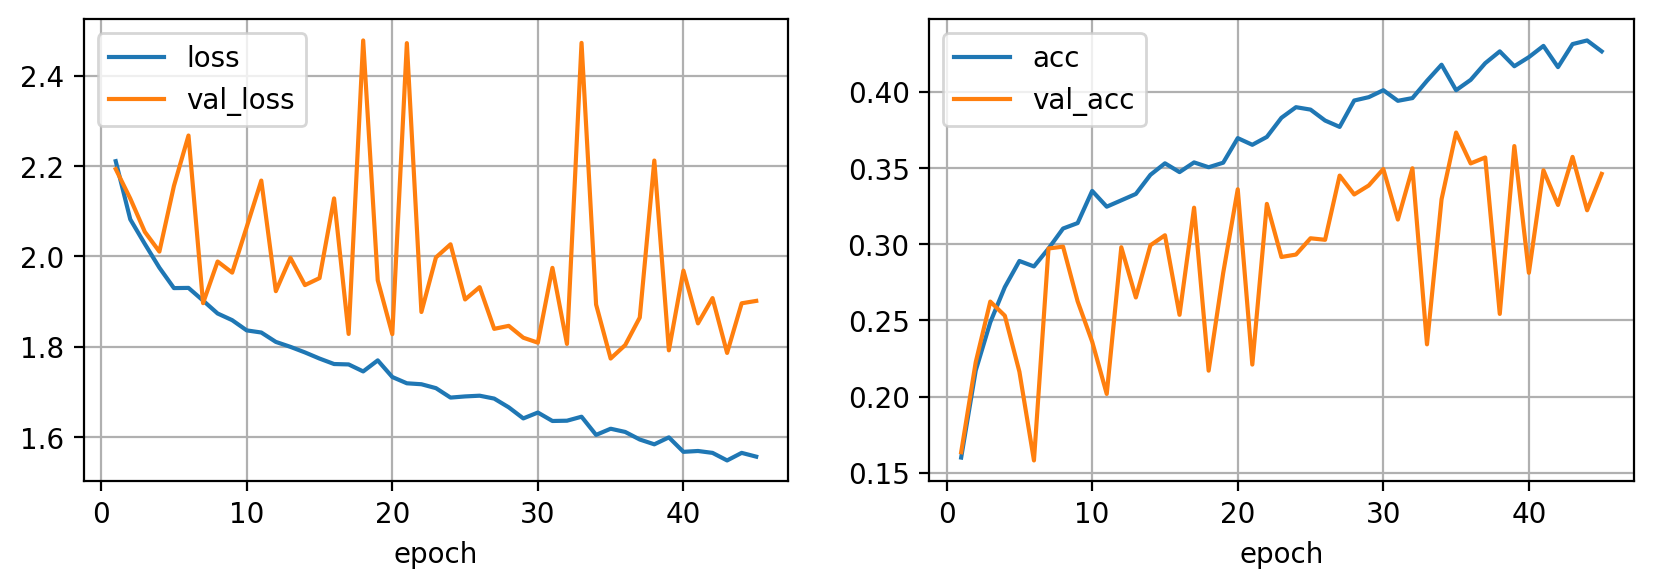

In [22]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section7"></a>
# <font color="#004D7F" size=6>7. Usar más datos</font>

La mejor manera de reducir el overfitting es usando más datos. Sin embargo, a diferencia del resto de estrategias presentadas hasta ahora, ésta no solo reducirá el overfitting si no que también mejorará las prestaciones de nuestro modelo.

In [23]:
dataset = {
    'train': Dataset(X_train, y_train),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(40000, 10000)

In [24]:
model = build_model()
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.29690 en epoch 1
Mejor modelo guardado con acc 0.33630 en epoch 2
Mejor modelo guardado con acc 0.39850 en epoch 3
Mejor modelo guardado con acc 0.40950 en epoch 5
Mejor modelo guardado con acc 0.43090 en epoch 6
Mejor modelo guardado con acc 0.43600 en epoch 7
Mejor modelo guardado con acc 0.45040 en epoch 9
Epoch 10/100 loss 1.47652 acc 0.47082 val_loss 1.54865 val_acc 0.44390
Mejor modelo guardado con acc 0.45210 en epoch 11
Mejor modelo guardado con acc 0.45690 en epoch 12
Mejor modelo guardado con acc 0.46310 en epoch 13
Entrenamiento detenido en epoch 18 por no mejorar en 5 epochs seguidas


- Como puedes observar el accuracy de nuestro modelo ha aumentado considerablemente gracias al uso de más datos. 
- De esta manera aprovechamos más capacidad del modelo.

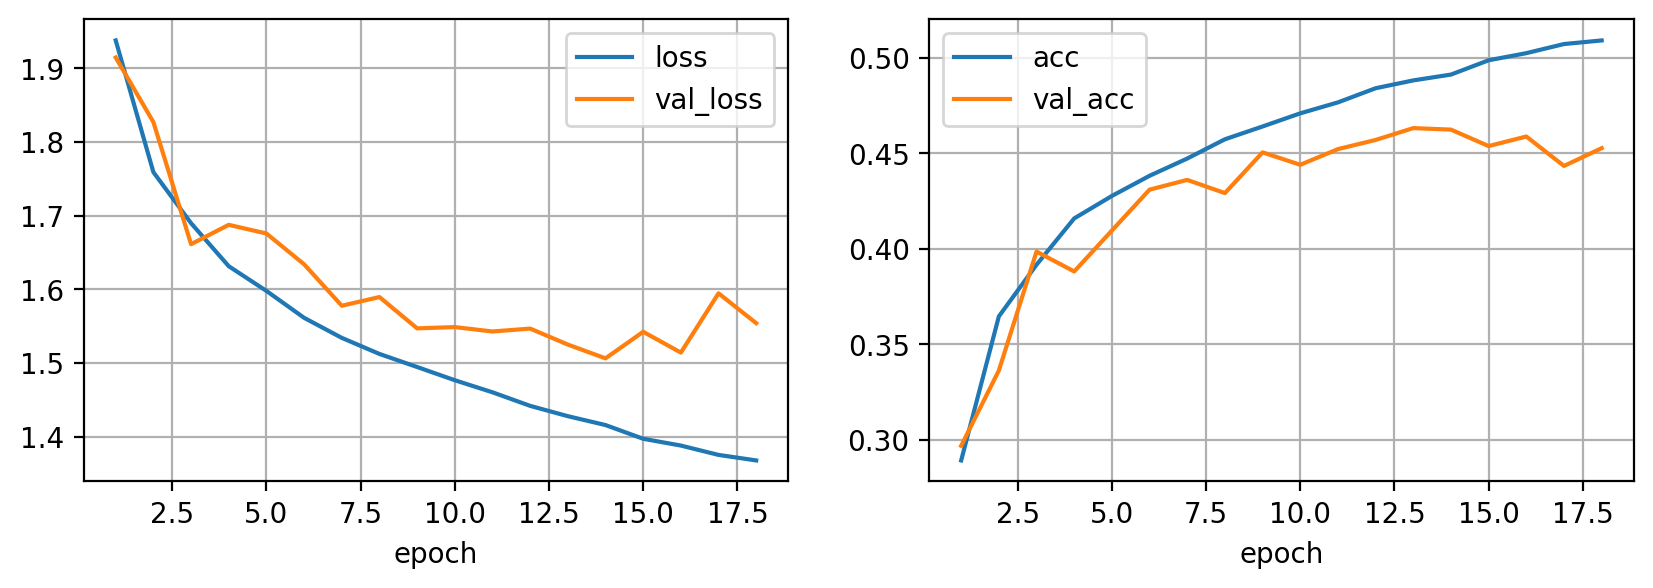

In [25]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section8"></a>
# <font color="#004D7F" size=6>8. Data Augmentation</font>

- Vamos a aplicar transformaciones de manera aleatoria de forma que, efectivamente, nuestro modelo no vea nunca la misma imagen dos veces consiguiendo así un dataset potencialmente infinito. 
- Estas transformaciones deben alterar la imagen lo suficiente como para poder considerarla como una muestra diferente pero no tanto como para alterar su etiqueta. 
- Algunos ejemplos de estas transformaciones incluyen: giros, recortes, alteraciones de color, brillo o tamaño, etc.

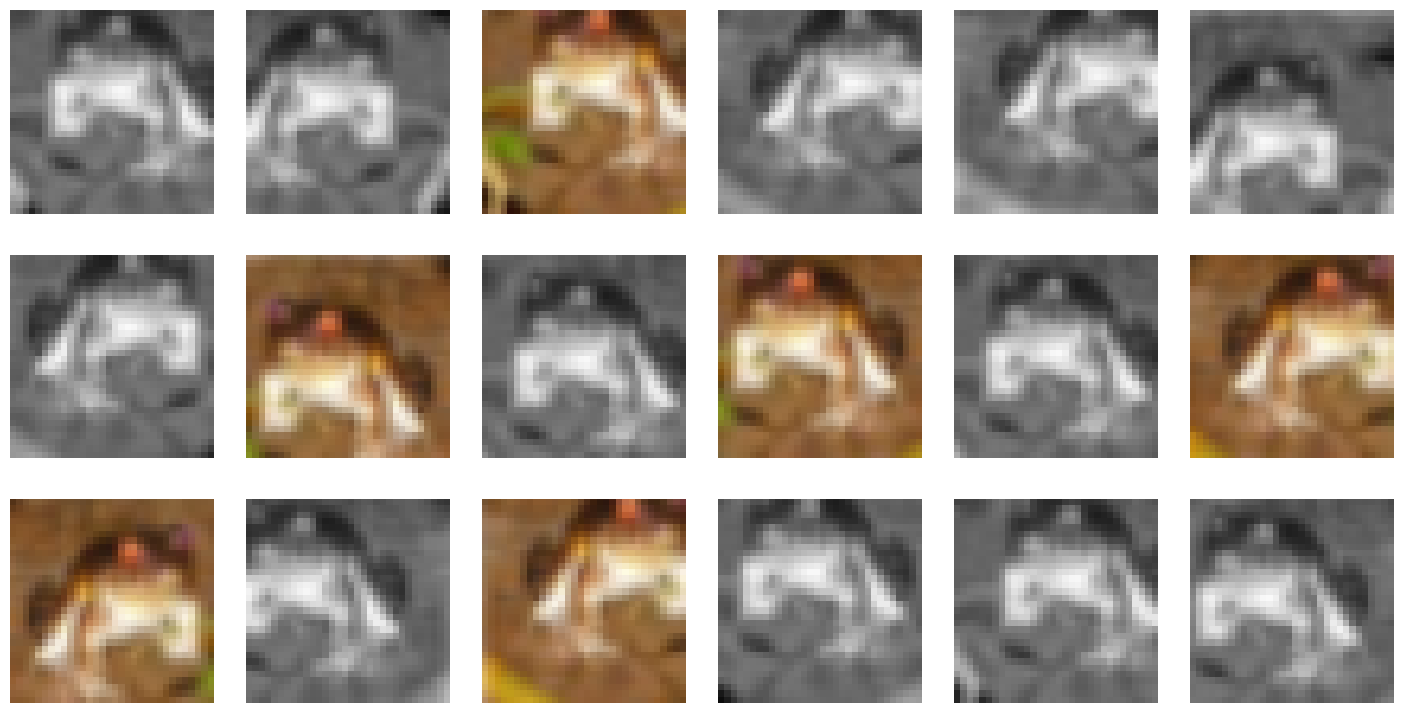

In [28]:
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Definir las transformaciones
trans = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.RandomResizedCrop(32, scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
])

# Ejemplo para visualizar transformaciones
idx = 0
r, c = 3, 6
plt.figure(figsize=(c * 3, r * 3))
for row in range(r):
    for col in range(c):
        ix = c * row + col
        plt.subplot(r, c, ix + 1)
        img, label = trainset[idx]
        # Aplicar transformación
        img = trans(img)  # cada llamada produce una versión aleatoria distinta
        plt.imshow(img)
        plt.axis('off')
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

- Estás viendo un única muestra de nuestro dataset a la cual le hemos aplicado una serie de transformaciones que han alterado su apariencia sin modificar su etiqueta. 
- Aplicando estas transformaciones aleatorias a cada muestra antes de dársela a la red neuronal obligará a nuestro a modelo a generalizar mucho más, reduciendo el overfitting. 

In [29]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y, trans=None):
        self.X = X
        self.Y = Y
        self.trans = trans

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        img = self.X[ix]
        if self.trans:
            img = self.trans(Image.fromarray(img))  # numpy -> PIL -> transformación aleatoria
        img = torch.from_numpy(np.array(img) / 255.).float().to(device).view(-1)  # Normalizar y convertir a tensor
        label = torch.tensor(self.Y[ix]).long().to(device)
        return img, label

dataset = {
    'train': Dataset(X_train, y_train, trans),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(40000, 10000)

Entrenamos el modelo

In [31]:
model = build_model()
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.28620 en epoch 1
Mejor modelo guardado con acc 0.31430 en epoch 3
Mejor modelo guardado con acc 0.32540 en epoch 4
Mejor modelo guardado con acc 0.33730 en epoch 5
Mejor modelo guardado con acc 0.34440 en epoch 6
Mejor modelo guardado con acc 0.35840 en epoch 7
Epoch 10/100 loss 1.90450 acc 0.30585 val_loss 1.83590 val_acc 0.33400
Entrenamiento detenido en epoch 12 por no mejorar en 5 epochs seguidas


- El uso de data augmentation requerirá de ciclos de entrenamiento más largos para poder aprovechar toda la capacidad que las transformaciones nos ofrecen. 
- Una característica interesante de esta técnica es que podemos conseguir que las curvas de aprendizaje de validación estén por encima de las de entrenamiento, indicando que nuestro modelo realmente trabaja mejor en datos no vistos.

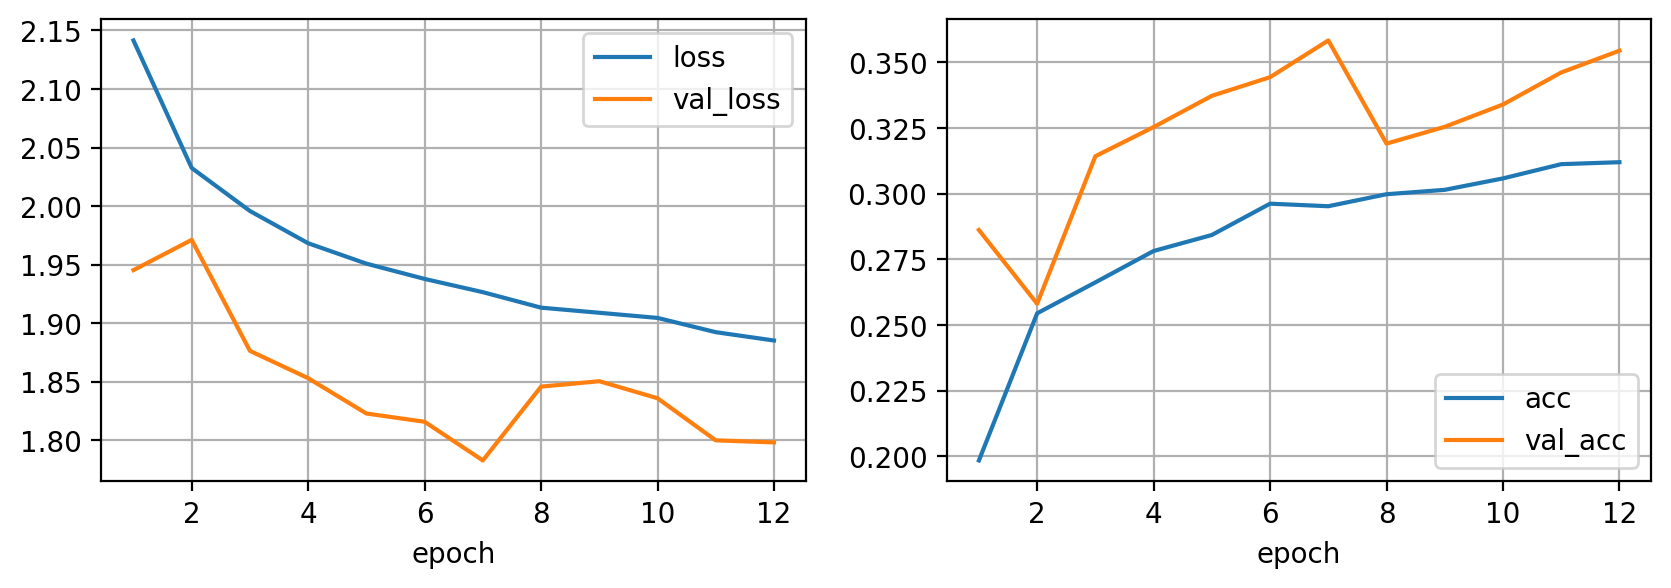

In [32]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>